# Práctica Clase 14: Validación Cruzada con K-NN y SVM

## Objetivos
- Implementar validación cruzada con K iteraciones para K-NN y SVM
- Implementar validación cruzada leave-one-out para ambos algoritmos
- Encontrar los mejores parámetros para cada algoritmo
- Comparar ambos métodos de validación

## 1. Importación de librerías

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, GridSearchCV, LeaveOneOut, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Carga y preparación de datos

In [9]:
# Cargar el dataset del proyecto
df = pd.read_csv('../jira_datasets/activemq-5.0.0.csv')  # Cambia por tu dataset

print(f"Shape del dataset: {df.shape}")
print(f"\nColumnas disponibles:")
print(df.columns.tolist())

Shape del dataset: (1884, 70)

Columnas disponibles:
['File', 'CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic', 'CountDeclMethodDefault', 'AvgEssential', 'CountDeclClassVariable', 'SumCyclomaticStrict', 'AvgCyclomatic', 'AvgLine', 'CountDeclClassMethod', 'AvgLineComment', 'AvgCyclomaticModified', 'CountDeclFunction', 'CountLineComment', 'CountDeclClass', 'CountDeclMethod', 'SumCyclomaticModified', 'CountLineCodeDecl', 'CountDeclMethodProtected', 'CountDeclInstanceVariable', 'MaxCyclomaticStrict', 'CountDeclMethodPublic', 'CountLineCodeExe', 'SumCyclomatic', 'SumEssential', 'CountStmtDecl', 'CountLineCode', 'CountStmtExe', 'RatioCommentToCode', 'CountLineBlank', 'CountStmt', 'MaxCyclomaticModified', 'CountSemicolon', 'AvgLineBlank', 'CountDeclInstanceMethod', 'AvgCyclomaticStrict', 'PercentLackOfCohesion', 'MaxInheritanceTree', 'CountClassDerived', 'CountClassCoupled', 'CountClassBase', 'CountInput_Max', 'CountInput_Mean', 'CountInput_Min', 'CountOutput_Max', 'Count

In [10]:
target_column = 'RealBug'

print(f"Distribución de clases:")
print(df[target_column].value_counts())
print(f"\nProporción de clases:")
print(df[target_column].value_counts(normalize=True))

Distribución de clases:
RealBug
False    1591
True      293
Name: count, dtype: int64

Proporción de clases:
RealBug
False    0.84448
True     0.15552
Name: proportion, dtype: float64


In [15]:
# Preparar características y variable objetivo
# Eliminar columnas no numéricas y la variable objetivo
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ['HeuBug', 'HeuBugCount', 'RealBug', 'RealBugCount']:
	if col in numeric_columns:
		numeric_columns.remove(col)

X = df[numeric_columns]
y = df[target_column]

print(f"Características seleccionadas: {len(X.columns)}")
print(f"Muestra de características: {X.columns[:5].tolist()}")

# Hacer split de datos 80-20
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Características seleccionadas: 65
Muestra de características: ['CountDeclMethodPrivate', 'AvgLineCode', 'CountLine', 'MaxCyclomatic', 'CountDeclMethodDefault']


## 3. Validación Cruzada con K iteraciones (K-Fold)

### 3.1 K-NN con K-Fold Cross Validation

In [16]:
# Definir parámetros a probar para K-NN
knn_param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Configurar K-Fold
k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search para K-NN
knn = KNeighborsClassifier()
knn_grid_search = GridSearchCV(
    knn, 
    knn_param_grid, 
    cv=k_fold, 
    scoring='accuracy',
    verbose=3
)

print("Ejecutando Grid Search para K-NN con K-Fold...")
knn_grid_search.fit(X_train, y_train)

print(f"\nMejores parámetros K-NN (K-Fold): {knn_grid_search.best_params_}")
print(f"Mejor score K-NN (K-Fold): {knn_grid_search.best_score_:.4f}")

Ejecutando Grid Search para K-NN con K-Fold...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV 1/5] END metric=euclidean, n_neighbors=1, weights=uniform;, score=0.848 total time=   0.1s
[CV 2/5] END metric=euclidean, n_neighbors=1, weights=uniform;, score=0.798 total time=   0.0s
[CV 3/5] END metric=euclidean, n_neighbors=1, weights=uniform;, score=0.801 total time=   0.0s
[CV 4/5] END metric=euclidean, n_neighbors=1, weights=uniform;, score=0.844 total time=   0.0s
[CV 5/5] END metric=euclidean, n_neighbors=1, weights=uniform;, score=0.817 total time=   0.0s
[CV 1/5] END metric=euclidean, n_neighbors=1, weights=distance;, score=0.848 total time=   0.0s
[CV 2/5] END metric=euclidean, n_neighbors=1, weights=distance;, score=0.798 total time=   0.0s
[CV 3/5] END metric=euclidean, n_neighbors=1, weights=distance;, score=0.801 total time=   0.0s
[CV 4/5] END metric=euclidean, n_neighbors=1, weights=distance;, score=0.844 total time=   0.0s
[CV 5/5] END metric=euclidean, n

In [17]:
# Entrenar X_train con los mejora hiperparámetros encontrados
best_knn = knn_grid_search.best_estimator_
best_knn.fit(X_train, y_train)
y_pred_knn = best_knn.predict(X_test)
print("\nReporte de clasificación K-NN en conjunto de prueba:")
print(classification_report(y_test, y_pred_knn))


Reporte de clasificación K-NN en conjunto de prueba:
              precision    recall  f1-score   support

       False       0.89      0.96      0.92       318
        True       0.62      0.36      0.45        59

    accuracy                           0.86       377
   macro avg       0.75      0.66      0.69       377
weighted avg       0.85      0.86      0.85       377



### 3.2 SVM con K-Fold Cross Validation

In [18]:
# Definir parámetros a probar para SVM
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1]
}

# Grid Search para SVM
svm = SVC()
svm_grid_search = GridSearchCV(
    svm, 
    svm_param_grid, 
    cv=k_fold, 
    scoring='accuracy',
    verbose=3
)

print("Ejecutando Grid Search para SVM con K-Fold...")
svm_grid_search.fit(X_train, y_train)

print(f"\nMejores parámetros SVM (K-Fold): {svm_grid_search.best_params_}")
print(f"Mejor score SVM (K-Fold): {svm_grid_search.best_score_:.4f}")

Ejecutando Grid Search para SVM con K-Fold...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ................C=0.1, gamma=scale;, score=0.844 total time=   0.1s
[CV 2/5] END ................C=0.1, gamma=scale;, score=0.844 total time=   0.0s
[CV 3/5] END ................C=0.1, gamma=scale;, score=0.847 total time=   0.0s
[CV 4/5] END ................C=0.1, gamma=scale;, score=0.844 total time=   0.0s
[CV 5/5] END ................C=0.1, gamma=scale;, score=0.844 total time=   0.0s
[CV 1/5] END .................C=0.1, gamma=auto;, score=0.844 total time=   0.1s
[CV 2/5] END .................C=0.1, gamma=auto;, score=0.844 total time=   0.1s
[CV 3/5] END .................C=0.1, gamma=auto;, score=0.847 total time=   0.1s
[CV 4/5] END .................C=0.1, gamma=auto;, score=0.844 total time=   0.1s
[CV 5/5] END .................C=0.1, gamma=auto;, score=0.844 total time=   0.1s
[CV 1/5] END ..................C=0.1, gamma=0.1;, score=0.844 total time=   0.1s
[C

In [19]:
# Entrenar X_train con los mejora hiperparámetros encontrados
best_svm = svm_grid_search.best_estimator_
best_svm.fit(X_train, y_train)
y_pred_svm = best_svm.predict(X_test)
print("\nReporte de clasificación SVM en conjunto de prueba:")
print(classification_report(y_test, y_pred_svm))


Reporte de clasificación SVM en conjunto de prueba:
              precision    recall  f1-score   support

       False       0.85      0.99      0.92       318
        True       0.71      0.08      0.15        59

    accuracy                           0.85       377
   macro avg       0.78      0.54      0.54       377
weighted avg       0.83      0.85      0.80       377



## 4. Validación Cruzada Leave-One-Out (LOO)

### 4.1 K-NN con Leave-One-Out

In [20]:
knn_param_grid_loo = {
    'n_neighbors': [1, 3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

# Configurar Leave-One-Out
loo = LeaveOneOut()

# Nota: LOO puede ser muy lento para datasets grandes
# Como el dataset es muy grande (>1000 muestras), usaremos una muestra aleatoria de 500 
if len(X_train) > 1000:
    print(f"Dataset grande ({len(X_train)} muestras). Usando muestra de 500 para LOO...")
    sample_indices = np.random.choice(len(X_train), 500, replace=False)
    X_loo = X_train.iloc[sample_indices]
    y_loo = y_train.iloc[sample_indices]
else:
    X_loo = X_train
    y_loo = y_train

# Grid Search para K-NN con LOO
knn_loo = KNeighborsClassifier()
knn_grid_search_loo = GridSearchCV(
    knn_loo, 
    knn_param_grid_loo, 
    cv=loo, 
    scoring='accuracy',
    verbose=3
)

print("Ejecutando Grid Search para K-NN con Leave-One-Out...")
knn_grid_search_loo.fit(X_loo, y_loo)

print(f"\nMejores parámetros K-NN (LOO): {knn_grid_search_loo.best_params_}")
print(f"Mejor score K-NN (LOO): {knn_grid_search_loo.best_score_:.4f}")

Dataset grande (1507 muestras). Usando muestra de 500 para LOO...
Ejecutando Grid Search para K-NN con Leave-One-Out...
Fitting 500 folds for each of 10 candidates, totalling 5000 fits
[CV 1/500] END ..n_neighbors=1, weights=uniform;, score=1.000 total time=   0.0s
[CV 2/500] END ..n_neighbors=1, weights=uniform;, score=1.000 total time=   0.0s
[CV 3/500] END ..n_neighbors=1, weights=uniform;, score=1.000 total time=   0.0s
[CV 4/500] END ..n_neighbors=1, weights=uniform;, score=0.000 total time=   0.0s
[CV 5/500] END ..n_neighbors=1, weights=uniform;, score=1.000 total time=   0.0s
[CV 6/500] END ..n_neighbors=1, weights=uniform;, score=1.000 total time=   0.0s
[CV 7/500] END ..n_neighbors=1, weights=uniform;, score=1.000 total time=   0.0s
[CV 8/500] END ..n_neighbors=1, weights=uniform;, score=0.000 total time=   0.0s
[CV 9/500] END ..n_neighbors=1, weights=uniform;, score=1.000 total time=   0.0s
[CV 10/500] END .n_neighbors=1, weights=uniform;, score=0.000 total time=   0.0s
[CV 1

In [23]:
# Entrenar X_train con los mejora hiperparámetros encontrados
best_loo_knn = knn_grid_search_loo.best_estimator_
best_loo_knn.fit(X_train, y_train)
y_pred_loo_knn = best_loo_knn.predict(X_test)
print("\nReporte de clasificación KNN en conjunto de prueba:")
print(classification_report(y_test, y_pred_loo_knn))


Reporte de clasificación KNN en conjunto de prueba:
              precision    recall  f1-score   support

       False       0.90      0.97      0.93       318
        True       0.68      0.39      0.49        59

    accuracy                           0.88       377
   macro avg       0.79      0.68      0.71       377
weighted avg       0.86      0.88      0.86       377



### 4.2 SVM con Leave-One-Out

In [24]:
svm_param_grid_loo = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1]
}

# Grid Search para SVM con LOO
svm_loo = SVC()
svm_grid_search_loo = GridSearchCV(
    svm_loo, 
    svm_param_grid_loo, 
    cv=loo, 
    scoring='accuracy',
    verbose=3
)

print("Ejecutando Grid Search para SVM con Leave-One-Out...")
svm_grid_search_loo.fit(X_loo, y_loo)

print(f"\nMejores parámetros SVM (LOO): {svm_grid_search_loo.best_params_}")
print(f"Mejor score SVM (LOO): {svm_grid_search_loo.best_score_:.4f}")

Ejecutando Grid Search para SVM con Leave-One-Out...
Fitting 500 folds for each of 9 candidates, totalling 4500 fits
[CV 1/500] END ..............C=0.1, gamma=scale;, score=1.000 total time=   0.0s
[CV 2/500] END ..............C=0.1, gamma=scale;, score=1.000 total time=   0.0s
[CV 3/500] END ..............C=0.1, gamma=scale;, score=1.000 total time=   0.0s
[CV 4/500] END ..............C=0.1, gamma=scale;, score=1.000 total time=   0.0s
[CV 5/500] END ..............C=0.1, gamma=scale;, score=1.000 total time=   0.0s
[CV 6/500] END ..............C=0.1, gamma=scale;, score=1.000 total time=   0.0s
[CV 7/500] END ..............C=0.1, gamma=scale;, score=1.000 total time=   0.0s
[CV 8/500] END ..............C=0.1, gamma=scale;, score=1.000 total time=   0.0s
[CV 9/500] END ..............C=0.1, gamma=scale;, score=1.000 total time=   0.0s
[CV 10/500] END .............C=0.1, gamma=scale;, score=0.000 total time=   0.0s
[CV 11/500] END .............C=0.1, gamma=scale;, score=0.000 total time=

In [25]:
# Entrenar X_train con los mejora hiperparámetros encontrados
best_loo_svm = svm_grid_search_loo.best_estimator_
best_loo_svm.fit(X_train, y_train)
y_pred_loo_svm = best_loo_svm.predict(X_test)
print("\nReporte de clasificación SVM en conjunto de prueba:")
print(classification_report(y_test, y_pred_loo_svm))


Reporte de clasificación SVM en conjunto de prueba:
              precision    recall  f1-score   support

       False       0.84      1.00      0.92       318
        True       0.00      0.00      0.00        59

    accuracy                           0.84       377
   macro avg       0.42      0.50      0.46       377
weighted avg       0.71      0.84      0.77       377



## 5. Comparación de Resultados

In [27]:
# Crear tabla de comparación
results = pd.DataFrame({
    'Algoritmo': ['K-NN', 'K-NN', 'SVM', 'SVM'],
    'Método': ['K-Fold', 'Leave-One-Out', 'K-Fold', 'Leave-One-Out'],
    'Mejor Score': [
        knn_grid_search.best_score_,
        knn_grid_search_loo.best_score_,
        svm_grid_search.best_score_,
        svm_grid_search_loo.best_score_
    ],
    'Mejores Parámetros': [
        str(knn_grid_search.best_params_),
        str(knn_grid_search_loo.best_params_),
        str(svm_grid_search.best_params_),
        str(svm_grid_search_loo.best_params_)
    ]
})

print("\n" + "="*80)
print("RESUMEN DE RESULTADOS")
print("="*80)
print(results.to_string(index=False))


RESUMEN DE RESULTADOS
Algoritmo        Método  Mejor Score                                                Mejores Parámetros
     K-NN        K-Fold     0.879226 {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
     K-NN Leave-One-Out     0.870000                          {'n_neighbors': 5, 'weights': 'uniform'}
      SVM        K-Fold     0.856672                                      {'C': 100, 'gamma': 'scale'}
      SVM Leave-One-Out     0.846000                                      {'C': 0.1, 'gamma': 'scale'}


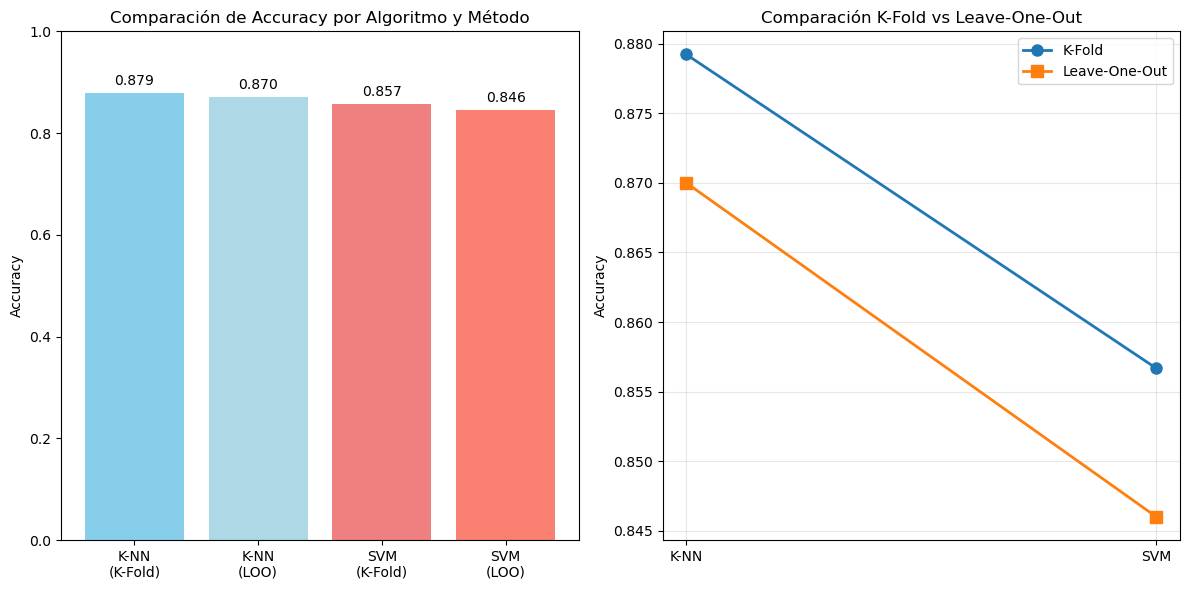

In [28]:
# Visualización de resultados
plt.figure(figsize=(12, 6))

# Gráfico de barras comparando los scores
plt.subplot(1, 2, 1)
algorithms = ['K-NN\n(K-Fold)', 'K-NN\n(LOO)', 'SVM\n(K-Fold)', 'SVM\n(LOO)']
scores = results['Mejor Score'].values
colors = ['skyblue', 'lightblue', 'lightcoral', 'salmon']

bars = plt.bar(algorithms, scores, color=colors)
plt.title('Comparación de Accuracy por Algoritmo y Método')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

# Añadir valores en las barras
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico de líneas para comparar métodos
plt.subplot(1, 2, 2)
kfold_scores = [knn_grid_search.best_score_, svm_grid_search.best_score_]
loo_scores = [knn_grid_search_loo.best_score_, svm_grid_search_loo.best_score_]
alg_names = ['K-NN', 'SVM']

plt.plot(alg_names, kfold_scores, 'o-', label='K-Fold', linewidth=2, markersize=8)
plt.plot(alg_names, loo_scores, 's-', label='Leave-One-Out', linewidth=2, markersize=8)
plt.title('Comparación K-Fold vs Leave-One-Out')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()